STEP W3: WEATHER-ENHANCED RIDGE EXPERIMENT
Mounted at /content/drive
/content/drive/MyDrive/Load_Forecasting_Paper/data/forecasting_weather/train_2015_2022_weather.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/data/forecasting_weather/validation_2023_weather.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/data/forecasting_weather/test_2024_2026_weather.csv -> True

DATASETS LOADED
TRAIN: 2236 2015-05-11 00:00:00 to 2022-12-31 00:00:00
VALIDATION: 273 2023-01-01 00:00:00 to 2023-12-28 00:00:00
TEST: 709 2024-01-01 00:00:00 to 2026-03-08 00:00:00

FEATURE DEFINITIONS
Frozen original features: 165
Weather features: 89
Combined candidate features: 254
Targets: 23

All required columns found.

TRAIN
Base feature NaNs: 0
Weather feature NaNs: 0
Target NaNs: 0

VALIDATION
Base feature NaNs: 0
Weather feature NaNs: 0
Target NaNs: 0

TEST
Base feature NaNs: 0
Weather feature NaNs: 0
Target NaNs: 0

No imputation required.

Constant weather features in TRAIN:
['wx_history28

,alpha,MAE_MW,RMSE_MW,MAPE_percent,sMAPE_percent
0,10.00,397.8412,622.7462,3.8157,3.7158
1,100.00,412.4188,634.3505,3.9544,3.8609
2,1.00,413.2879,635.3414,3.9503,3.8538
3,0.10,428.3626,647.5356,4.0810,3.9905
4,0.01,434.0624,652.0904,4.1368,4.0466
5,1000.00,484.0675,699.9426,4.6319,4.5424



VALIDATION COMPARISON


,model,features,alpha,MAE_MW,RMSE_MW,MAPE_percent,sMAPE_percent,MAE_change_vs_baseline_MW
0,Frozen_Ridge_165,165,10.0,409.5962,635.5469,3.9084,3.8083,0.0000
1,Ridge_Plus_Weather,254,10.0,397.8412,622.7462,3.8157,3.7158,-11.7549



Combined TRAIN + VALIDATION: 2509

LOCKED TEST COMPARISON


...


Positive improvement means weather reduced MAE.
Weather MAE improvement: -8.718 MW
Weather MAE skill vs frozen Ridge: -1.994 %

FROZEN BASELINE REPRODUCTION CHECK
Current baseline MAE: 437.156494
Reference MAE: 437.159
Difference: -0.002506 MW
Baseline reproduction PASSED.

TEMPORAL WEATHER COMPARISON


,period,samples,baseline_MAE_MW,weather_MAE_MW,MAE_improvement_MW,weather_skill_percent,baseline_MAPE_percent,weather_MAPE_percent
0,TEST_A_2024,298,463.2716,476.1169,-12.8452,-2.7727,4.1026,4.1951
1,TEST_B_2025_2026,411,418.2215,423.9474,-5.7259,-1.3691,3.5434,3.6215
2,ALL_TEST_2024_2026,709,437.1565,445.8748,-8.7183,-1.9943,3.7784,3.8626



HORIZON-WISE WEATHER EFFECT


,hour,baseline_MAE_MW,weather_MAE_MW,weather_improvement_MW,weather_skill_percent
0,1,196.8270,197.3520,-0.5250,-0.2668
1,2,214.3627,213.0668,1.2959,0.6045
2,3,231.6920,238.7550,-7.0630,-3.0485
3,4,270.3999,284.9193,-14.5194,-5.3696
4,5,281.3841,295.5355,-14.1514,-5.0292
5,6,309.9003,317.0356,-7.1353,-2.3024
6,7,381.2994,383.4044,-2.1049,-0.5520
7,8,394.1678,396.1002,-1.9325,-0.4903
8,9,413.9716,424.2888,-10.3173,-2.4923
9,10,433.7333,449.9707,-16.2374,-3.7436



DAILY PAIRED SUMMARY
Mean daily improvement: -8.718 MW
Weather model better on: 45.84 % of test days


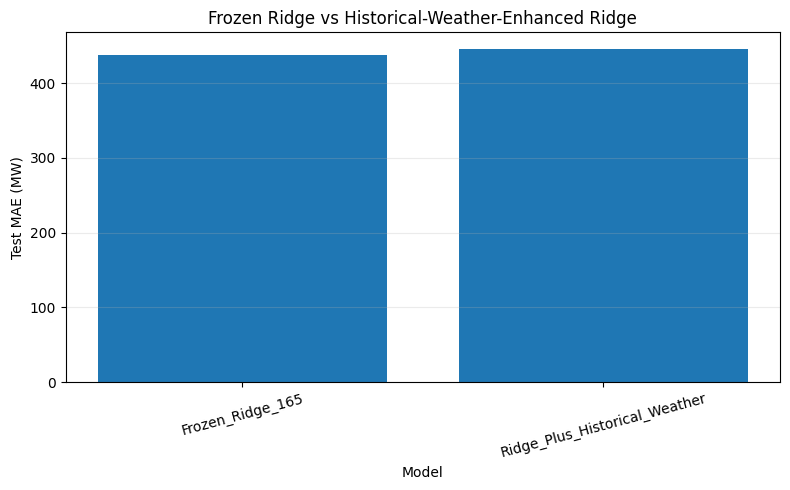



STEP W3 COMPLETED SUCCESSFULLY

FROZEN RIDGE:
Features: 165
Alpha: 10.0
MAE: 437.156 MW
RMSE: 648.567 MW
MAPE: 3.778 %

RIDGE + HISTORICAL WEATHER:
Features: 254
Selected alpha: 10.0
MAE: 445.875 MW
RMSE: 652.795 MW
MAPE: 3.863 %

WEATHER EFFECT:
MAE improvement: -8.718 MW
Relative skill: -1.994 %

Result files:
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_ridge_validation_tuning.csv
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_test_leaderboard.csv
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_temporal_comparison.csv
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_hourly_comparison.csv
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_daily_paired_errors.csv
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_vs_baseline_test_predictions.csv
/content/drive/MyDrive/Load_Forecasting_Paper/result

In [ ]:
# ======================================================================
# STEP W3
# WEATHER-ENHANCED RIDGE EXPERIMENT
#
# PURPOSE
# -------
# Controlled comparison:
#
#   Model A:
#       Frozen Ridge baseline
#       165 original load/calendar features
#       alpha = 10
#
#   Model B:
#       Ridge + causal historical weather
#       165 original + 89 weather features = 254 candidate features
#
# MODEL SELECTION:
#   Train       = 2015-2022
#   Validation  = 2023
#   Test        = 2024-01-01 to 2026-03-08
#
# Weather Ridge alpha is selected ONLY on validation.
#
# After alpha selection:
#   Train + Validation are combined.
#   Test is evaluated once.
#
# IMPORTANT:
#   Weather predictors contain D-1 and earlier observations only.
#   There is NO target-day realized weather.
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import joblib

from google.colab import drive
from IPython.display import display


warnings.filterwarnings("ignore")

np.random.seed(42)

pd.set_option("display.max_columns", 350)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 300)


print("=" * 120)
print("STEP W3: WEATHER-ENHANCED RIDGE EXPERIMENT")
print("=" * 120)


# ======================================================================
# 1. MOUNT DRIVE
# ======================================================================

drive.mount(
    "/content/drive"
)


# ======================================================================
# 2. PATHS
# ======================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)

WEATHER_FORECAST_DIR = (
    PROJECT_ROOT
    / "data"
    / "forecasting_weather"
)

RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "weather_extension"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "weather_extension"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "weather_extension"
)


for directory in [

    RESULT_DIR,
    MODEL_DIR,
    FIGURE_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ======================================================================
# 3. INPUT FILES
# ======================================================================

TRAIN_FILE = (
    WEATHER_FORECAST_DIR
    / "train_2015_2022_weather.csv"
)

VALIDATION_FILE = (
    WEATHER_FORECAST_DIR
    / "validation_2023_weather.csv"
)

TEST_FILE = (
    WEATHER_FORECAST_DIR
    / "test_2024_2026_weather.csv"
)


for path in [

    TRAIN_FILE,
    VALIDATION_FILE,
    TEST_FILE

]:

    print(
        path,
        "->",
        path.exists()
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Required W2 file missing: {path}"
        )


# ======================================================================
# 4. LOAD DATA
# ======================================================================

train_df = pd.read_csv(
    TRAIN_FILE,
    low_memory=False
)

validation_df = pd.read_csv(
    VALIDATION_FILE,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_FILE,
    low_memory=False
)


for df in [

    train_df,
    validation_df,
    test_df

]:

    df["target_date"] = pd.to_datetime(
        df["target_date"],
        errors="coerce"
    )

    df.sort_values(
        "target_date",
        inplace=True
    )

    df.reset_index(
        drop=True,
        inplace=True
    )


print("\n" + "=" * 120)
print("DATASETS LOADED")
print("=" * 120)

print(
    "TRAIN:",
    len(train_df),
    train_df["target_date"].min(),
    "to",
    train_df["target_date"].max()
)

print(
    "VALIDATION:",
    len(validation_df),
    validation_df["target_date"].min(),
    "to",
    validation_df["target_date"].max()
)

print(
    "TEST:",
    len(test_df),
    test_df["target_date"].min(),
    "to",
    test_df["target_date"].max()
)


# ======================================================================
# 5. TARGETS
# ======================================================================

HOURS = list(
    range(
        1,
        24
    )
)


TARGET_COLUMNS = [

    f"target_h{hour:02d}"

    for hour in HOURS

]


assert len(
    TARGET_COLUMNS
) == 23


# ======================================================================
# 6. FROZEN ORIGINAL 165 FEATURES
# ======================================================================

CALENDAR_FEATURES = [

    "year",
    "month",
    "day",
    "dayofweek",
    "dayofyear",
    "weekofyear",
    "quarter",
    "is_weekend",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos"

]


PREVIOUS_DAY_PROFILE = [

    f"lag1_h{hour:02d}"

    for hour in HOURS

]


PREVIOUS_WEEK_PROFILE = [

    f"lag7_h{hour:02d}"

    for hour in HOURS

]


ROLLING7_MEAN = [

    f"roll7mean_h{hour:02d}"

    for hour in HOURS

]


ROLLING28_MEAN = [

    f"roll28mean_h{hour:02d}"

    for hour in HOURS

]


ROLLING7_STD = [

    f"roll7std_h{hour:02d}"

    for hour in HOURS

]


ROLLING28_STD = [

    f"roll28std_h{hour:02d}"

    for hour in HOURS

]


HISTORICAL_SUMMARY = [

    "lag1_daily_mean",
    "lag1_daily_max",
    "lag1_daily_min",
    "lag1_daily_range",
    "lag1_peak_hour",

    "lag7_daily_mean",
    "lag7_daily_max",
    "lag7_daily_min",
    "lag7_daily_range",
    "lag7_peak_hour",

    "mean_change_vs_last_week",
    "max_change_vs_last_week",
    "mean_ratio_vs_last_week"

]


BASE_FEATURE_COLUMNS = (

    PREVIOUS_DAY_PROFILE
    +
    PREVIOUS_WEEK_PROFILE
    +
    ROLLING7_MEAN
    +
    ROLLING28_MEAN
    +
    ROLLING7_STD
    +
    ROLLING28_STD
    +
    CALENDAR_FEATURES
    +
    HISTORICAL_SUMMARY

)


assert (
    len(
        BASE_FEATURE_COLUMNS
    )
    ==
    165
)


# ======================================================================
# 7. WEATHER FEATURES
# ======================================================================

WEATHER_FEATURE_COLUMNS = [

    column

    for column in train_df.columns

    if column.startswith(
        "wx_"
    )

]


WEATHER_FEATURE_COLUMNS = sorted(
    WEATHER_FEATURE_COLUMNS
)


validation_weather_columns = sorted([

    column

    for column in validation_df.columns

    if column.startswith(
        "wx_"
    )

])


test_weather_columns = sorted([

    column

    for column in test_df.columns

    if column.startswith(
        "wx_"
    )

])


assert (
    WEATHER_FEATURE_COLUMNS
    ==
    validation_weather_columns
    ==
    test_weather_columns
)


print("\n" + "=" * 120)
print("FEATURE DEFINITIONS")
print("=" * 120)


print(
    "Frozen original features:",
    len(
        BASE_FEATURE_COLUMNS
    )
)

print(
    "Weather features:",
    len(
        WEATHER_FEATURE_COLUMNS
    )
)


COMBINED_FEATURE_COLUMNS = (

    BASE_FEATURE_COLUMNS
    +
    WEATHER_FEATURE_COLUMNS

)


print(
    "Combined candidate features:",
    len(
        COMBINED_FEATURE_COLUMNS
    )
)


print(
    "Targets:",
    len(
        TARGET_COLUMNS
    )
)


# ======================================================================
# 8. COLUMN VALIDATION
# ======================================================================

for split_name, df in [

    ("TRAIN", train_df),
    ("VALIDATION", validation_df),
    ("TEST", test_df)

]:

    required = (

        BASE_FEATURE_COLUMNS
        +
        WEATHER_FEATURE_COLUMNS
        +
        TARGET_COLUMNS

    )


    missing = [

        column

        for column in required

        if column not in df.columns

    ]


    if missing:

        raise ValueError(
            f"{split_name}: missing columns: {missing}"
        )


print(
    "\nAll required columns found."
)


# ======================================================================
# 9. FINITE / MISSING VALUE CHECK
# ======================================================================

for split_name, df in [

    ("TRAIN", train_df),
    ("VALIDATION", validation_df),
    ("TEST", test_df)

]:

    base_nan = int(

        df[
            BASE_FEATURE_COLUMNS
        ]
        .isna()
        .sum()
        .sum()

    )


    weather_nan = int(

        df[
            WEATHER_FEATURE_COLUMNS
        ]
        .isna()
        .sum()
        .sum()

    )


    target_nan = int(

        df[
            TARGET_COLUMNS
        ]
        .isna()
        .sum()
        .sum()

    )


    print(
        f"\n{split_name}"
    )

    print(
        "Base feature NaNs:",
        base_nan
    )

    print(
        "Weather feature NaNs:",
        weather_nan
    )

    print(
        "Target NaNs:",
        target_nan
    )


    if (
        base_nan > 0
        or weather_nan > 0
        or target_nan > 0
    ):

        raise ValueError(
            f"{split_name}: missing values remain."
        )


print(
    "\nNo imputation required."
)


# ======================================================================
# 10. DETECT CONSTANT WEATHER FEATURES
# ======================================================================
#
# Availability variables may be constant because W0/W1 now give
# complete historical weather coverage.
#
# We report them but do NOT use test information to decide anything.
# Detection is based ONLY on TRAIN.
# ======================================================================

constant_weather_features = [

    column

    for column in WEATHER_FEATURE_COLUMNS

    if train_df[
        column
    ].nunique(
        dropna=False
    ) <= 1

]


print("\nConstant weather features in TRAIN:")

print(
    constant_weather_features
)


# Keeping constants is mathematically harmless after StandardScaler.
# To preserve the exact 89-feature W2 definition, they remain included.


# ======================================================================
# 11. NUMPY MATRICES
# ======================================================================

X_train_base = (
    train_df[
        BASE_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_val_base = (
    validation_df[
        BASE_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_test_base = (
    test_df[
        BASE_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


X_train_weather = (
    train_df[
        COMBINED_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_val_weather = (
    validation_df[
        COMBINED_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_test_weather = (
    test_df[
        COMBINED_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


Y_train = (
    train_df[
        TARGET_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

Y_val = (
    validation_df[
        TARGET_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

Y_test = (
    test_df[
        TARGET_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


print("\nMatrix shapes:")

print(
    "Baseline train:",
    X_train_base.shape
)

print(
    "Weather train:",
    X_train_weather.shape
)

print(
    "Target train:",
    Y_train.shape
)


# ======================================================================
# 12. METRICS
# ======================================================================

def mae(
    actual,
    predicted
):

    return float(
        np.mean(
            np.abs(
                actual
                -
                predicted
            )
        )
    )


def rmse(
    actual,
    predicted
):

    return float(
        np.sqrt(
            np.mean(
                (
                    actual
                    -
                    predicted
                )
                ** 2
            )
        )
    )


def mape(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    denominator = np.maximum(
        np.abs(
            actual
        ),
        1e-6
    )

    return float(

        100
        *
        np.mean(

            np.abs(
                actual
                -
                predicted
            )

            /
            denominator
        )
    )


def smape(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    denominator = (

        np.abs(
            actual
        )

        +

        np.abs(
            predicted
        )

    )


    denominator = np.maximum(
        denominator,
        1e-6
    )


    return float(

        100
        *
        np.mean(

            2
            *
            np.abs(
                predicted
                -
                actual
            )

            /
            denominator
        )
    )


def evaluate(
    actual,
    predicted
):

    return {

        "MAE_MW":
            mae(
                actual,
                predicted
            ),

        "RMSE_MW":
            rmse(
                actual,
                predicted
            ),

        "MAPE_percent":
            mape(
                actual,
                predicted
            ),

        "sMAPE_percent":
            smape(
                actual,
                predicted
            )

    }


# ======================================================================
# 13. FROZEN BASELINE VALIDATION
# ======================================================================
#
# Baseline alpha remains frozen at 10.
# We do NOT retune the original model.
# ======================================================================

BASELINE_ALPHA = 10.0


baseline_val_scaler = StandardScaler()


X_train_base_scaled = (
    baseline_val_scaler
    .fit_transform(
        X_train_base
    )
)


X_val_base_scaled = (
    baseline_val_scaler
    .transform(
        X_val_base
    )
)


baseline_val_model = Ridge(
    alpha=
        BASELINE_ALPHA
)


baseline_val_model.fit(
    X_train_base_scaled,
    Y_train
)


BASELINE_VAL_PRED = (
    baseline_val_model.predict(
        X_val_base_scaled
    )
)


baseline_val_metrics = evaluate(
    Y_val,
    BASELINE_VAL_PRED
)


print("\n" + "=" * 120)
print("FROZEN BASELINE — VALIDATION")
print("=" * 120)


print(
    "Alpha:",
    BASELINE_ALPHA
)

print(
    "MAE:",
    round(
        baseline_val_metrics[
            "MAE_MW"
        ],
        3
    ),
    "MW"
)

print(
    "MAPE:",
    round(
        baseline_val_metrics[
            "MAPE_percent"
        ],
        3
    ),
    "%"
)


# ======================================================================
# 14. WEATHER RIDGE VALIDATION SEARCH
# ======================================================================
#
# Same prespecified alpha grid used by the original Ridge study.
#
# TEST IS NOT USED HERE.
# ======================================================================

ALPHA_GRID = [

    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0

]


weather_val_scaler = StandardScaler()


X_train_weather_scaled = (
    weather_val_scaler
    .fit_transform(
        X_train_weather
    )
)


X_val_weather_scaled = (
    weather_val_scaler
    .transform(
        X_val_weather
    )
)


weather_tuning_rows = []


print("\n" + "=" * 120)
print("RIDGE + WEATHER VALIDATION SEARCH")
print("=" * 120)


for alpha in ALPHA_GRID:

    model = Ridge(
        alpha=
            alpha
    )


    model.fit(
        X_train_weather_scaled,
        Y_train
    )


    pred = model.predict(
        X_val_weather_scaled
    )


    metrics = evaluate(
        Y_val,
        pred
    )


    weather_tuning_rows.append({

        "alpha":
            alpha,

        **metrics

    })


    print(
        f"alpha={alpha:<8}",
        f"MAE={metrics['MAE_MW']:.3f} MW",
        f"MAPE={metrics['MAPE_percent']:.3f}%"
    )


weather_tuning = pd.DataFrame(
    weather_tuning_rows
)


weather_tuning = (

    weather_tuning

    .sort_values(
        "MAE_MW"
    )

    .reset_index(
        drop=True
    )

)


BEST_WEATHER_ALPHA = float(

    weather_tuning
    .iloc[0][
        "alpha"
    ]

)


print(
    "\nBest weather Ridge alpha:",
    BEST_WEATHER_ALPHA
)


display(
    weather_tuning.round(4)
)


WEATHER_TUNING_FILE = (
    RESULT_DIR
    / "weather_ridge_validation_tuning.csv"
)


weather_tuning.to_csv(
    WEATHER_TUNING_FILE,
    index=False
)


# ======================================================================
# 15. VALIDATION COMPARISON
# ======================================================================

best_weather_val = (
    weather_tuning
    .iloc[0]
)


validation_comparison = pd.DataFrame([

    {

        "model":
            "Frozen_Ridge_165",

        "features":
            len(
                BASE_FEATURE_COLUMNS
            ),

        "alpha":
            BASELINE_ALPHA,

        **baseline_val_metrics

    },

    {

        "model":
            "Ridge_Plus_Weather",

        "features":
            len(
                COMBINED_FEATURE_COLUMNS
            ),

        "alpha":
            BEST_WEATHER_ALPHA,

        "MAE_MW":
            float(
                best_weather_val[
                    "MAE_MW"
                ]
            ),

        "RMSE_MW":
            float(
                best_weather_val[
                    "RMSE_MW"
                ]
            ),

        "MAPE_percent":
            float(
                best_weather_val[
                    "MAPE_percent"
                ]
            ),

        "sMAPE_percent":
            float(
                best_weather_val[
                    "sMAPE_percent"
                ]
            )

    }

])


validation_comparison[
    "MAE_change_vs_baseline_MW"
] = (

    validation_comparison[
        "MAE_MW"
    ]

    -

    baseline_val_metrics[
        "MAE_MW"
    ]

)


print("\n" + "=" * 120)
print("VALIDATION COMPARISON")
print("=" * 120)


display(
    validation_comparison.round(4)
)


validation_comparison.to_csv(

    RESULT_DIR
    / "weather_validation_comparison.csv",

    index=False
)


# ======================================================================
# 16. COMBINE TRAIN + VALIDATION
# ======================================================================

train_val_df = pd.concat(

    [
        train_df,
        validation_df
    ],

    axis=0,

    ignore_index=True
)


train_val_df = (

    train_val_df

    .sort_values(
        "target_date"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nCombined TRAIN + VALIDATION:",
    len(
        train_val_df
    )
)


# ======================================================================
# 17. FINAL BASELINE FIT
# ======================================================================

X_train_val_base = (

    train_val_df[
        BASE_FEATURE_COLUMNS
    ]

    .to_numpy(
        dtype=np.float32
    )
)


Y_train_val = (

    train_val_df[
        TARGET_COLUMNS
    ]

    .to_numpy(
        dtype=np.float32
    )
)


final_baseline_scaler = StandardScaler()


X_train_val_base_scaled = (

    final_baseline_scaler

    .fit_transform(
        X_train_val_base
    )
)


X_test_base_scaled = (

    final_baseline_scaler

    .transform(
        X_test_base
    )
)


final_baseline_model = Ridge(
    alpha=
        BASELINE_ALPHA
)


final_baseline_model.fit(

    X_train_val_base_scaled,

    Y_train_val
)


BASELINE_TEST_PRED = (

    final_baseline_model

    .predict(
        X_test_base_scaled
    )
)


# ======================================================================
# 18. FINAL WEATHER RIDGE FIT
# ======================================================================

X_train_val_weather = (

    train_val_df[
        COMBINED_FEATURE_COLUMNS
    ]

    .to_numpy(
        dtype=np.float32
    )
)


final_weather_scaler = StandardScaler()


X_train_val_weather_scaled = (

    final_weather_scaler

    .fit_transform(
        X_train_val_weather
    )
)


X_test_weather_scaled = (

    final_weather_scaler

    .transform(
        X_test_weather
    )
)


final_weather_model = Ridge(

    alpha=
        BEST_WEATHER_ALPHA

)


final_weather_model.fit(

    X_train_val_weather_scaled,

    Y_train_val

)


WEATHER_TEST_PRED = (

    final_weather_model

    .predict(
        X_test_weather_scaled
    )
)


# ======================================================================
# 19. ALL-TEST PERFORMANCE
# ======================================================================

baseline_test_metrics = evaluate(

    Y_test,

    BASELINE_TEST_PRED
)


weather_test_metrics = evaluate(

    Y_test,

    WEATHER_TEST_PRED
)


TEST_MAE_IMPROVEMENT_MW = (

    baseline_test_metrics[
        "MAE_MW"
    ]

    -

    weather_test_metrics[
        "MAE_MW"
    ]
)


TEST_MAE_SKILL_PERCENT = (

    100

    *

    (
        1

        -

        weather_test_metrics[
            "MAE_MW"
        ]

        /

        baseline_test_metrics[
            "MAE_MW"
        ]
    )

)


test_leaderboard = pd.DataFrame([

    {

        "model":
            "Frozen_Ridge_165",

        "features":
            len(
                BASE_FEATURE_COLUMNS
            ),

        "alpha":
            BASELINE_ALPHA,

        **baseline_test_metrics

    },

    {

        "model":
            "Ridge_Plus_Historical_Weather",

        "features":
            len(
                COMBINED_FEATURE_COLUMNS
            ),

        "alpha":
            BEST_WEATHER_ALPHA,

        **weather_test_metrics

    }

])


print("\n" + "=" * 120)
print("LOCKED TEST COMPARISON")
print("=" * 120)


display(
    test_leaderboard.round(4)
)


print(
    "\nPositive improvement means weather reduced MAE."
)


print(
    "Weather MAE improvement:",
    round(
        TEST_MAE_IMPROVEMENT_MW,
        3
    ),
    "MW"
)


print(
    "Weather MAE skill vs frozen Ridge:",
    round(
        TEST_MAE_SKILL_PERCENT,
        3
    ),
    "%"
)


# ======================================================================
# 20. BASELINE REPRODUCTION CHECK
# ======================================================================
#
# Original frozen result was approximately 437.159 MW.
# ======================================================================

REFERENCE_BASELINE_MAE = 437.159


difference_from_reference = (

    baseline_test_metrics[
        "MAE_MW"
    ]

    -

    REFERENCE_BASELINE_MAE
)


print("\n" + "=" * 120)
print("FROZEN BASELINE REPRODUCTION CHECK")
print("=" * 120)


print(
    "Current baseline MAE:",
    round(
        baseline_test_metrics[
            "MAE_MW"
        ],
        6
    )
)


print(
    "Reference MAE:",
    REFERENCE_BASELINE_MAE
)


print(
    "Difference:",
    round(
        difference_from_reference,
        6
    ),
    "MW"
)


if abs(
    difference_from_reference
) <= 0.1:

    print(
        "Baseline reproduction PASSED."
    )

else:

    print(
        "WARNING: baseline reproduction differs by >0.1 MW."
    )


# ======================================================================
# 21. TEST-A / TEST-B ANALYSIS
# ======================================================================

TEST_A_MASK = (

    test_df[
        "target_date"
    ].dt.year
    ==
    2024

)


TEST_B_MASK = (

    test_df[
        "target_date"
    ].dt.year
    >=
    2025

)


period_rows = []


for period_name, mask in [

    ("TEST_A_2024", TEST_A_MASK),

    (
        "TEST_B_2025_2026",
        TEST_B_MASK
    ),

    (
        "ALL_TEST_2024_2026",
        np.ones(
            len(
                test_df
            ),
            dtype=bool
        )
    )

]:

    actual = Y_test[
        mask
    ]

    baseline_pred = BASELINE_TEST_PRED[
        mask
    ]

    weather_pred = WEATHER_TEST_PRED[
        mask
    ]


    baseline_metrics = evaluate(
        actual,
        baseline_pred
    )

    weather_metrics = evaluate(
        actual,
        weather_pred
    )


    period_rows.append({

        "period":
            period_name,

        "samples":
            int(
                np.sum(
                    mask
                )
            ),

        "baseline_MAE_MW":
            baseline_metrics[
                "MAE_MW"
            ],

        "weather_MAE_MW":
            weather_metrics[
                "MAE_MW"
            ],

        "MAE_improvement_MW":
            (
                baseline_metrics[
                    "MAE_MW"
                ]
                -
                weather_metrics[
                    "MAE_MW"
                ]
            ),

        "weather_skill_percent":
            (
                100
                *
                (
                    1
                    -
                    weather_metrics[
                        "MAE_MW"
                    ]
                    /
                    baseline_metrics[
                        "MAE_MW"
                    ]
                )
            ),

        "baseline_MAPE_percent":
            baseline_metrics[
                "MAPE_percent"
            ],

        "weather_MAPE_percent":
            weather_metrics[
                "MAPE_percent"
            ]

    })


period_results = pd.DataFrame(
    period_rows
)


print("\n" + "=" * 120)
print("TEMPORAL WEATHER COMPARISON")
print("=" * 120)


display(
    period_results.round(4)
)


# ======================================================================
# 22. HORIZON-WISE PERFORMANCE
# ======================================================================

hourly_rows = []


for index, hour in enumerate(
    HOURS
):

    actual = Y_test[
        :,
        index
    ]


    baseline_pred = BASELINE_TEST_PRED[
        :,
        index
    ]


    weather_pred = WEATHER_TEST_PRED[
        :,
        index
    ]


    baseline_hour_mae = mae(
        actual,
        baseline_pred
    )


    weather_hour_mae = mae(
        actual,
        weather_pred
    )


    hourly_rows.append({

        "hour":
            hour,

        "baseline_MAE_MW":
            baseline_hour_mae,

        "weather_MAE_MW":
            weather_hour_mae,

        "weather_improvement_MW":
            (
                baseline_hour_mae
                -
                weather_hour_mae
            ),

        "weather_skill_percent":
            (
                100
                *
                (
                    1
                    -
                    weather_hour_mae
                    /
                    baseline_hour_mae
                )
            )

    })


hourly_results = pd.DataFrame(
    hourly_rows
)


print("\n" + "=" * 120)
print("HORIZON-WISE WEATHER EFFECT")
print("=" * 120)


display(
    hourly_results.round(4)
)


# ======================================================================
# 23. DAILY PAIRED ERRORS
# ======================================================================
#
# This will be used in W4 for formal paired significance testing.
# ======================================================================

baseline_daily_mae = np.mean(

    np.abs(

        Y_test

        -

        BASELINE_TEST_PRED

    ),

    axis=1
)


weather_daily_mae = np.mean(

    np.abs(

        Y_test

        -

        WEATHER_TEST_PRED

    ),

    axis=1
)


daily_comparison = pd.DataFrame({

    "target_date":
        test_df[
            "target_date"
        ],

    "baseline_daily_MAE_MW":
        baseline_daily_mae,

    "weather_daily_MAE_MW":
        weather_daily_mae

})


daily_comparison[
    "weather_improvement_MW"
] = (

    daily_comparison[
        "baseline_daily_MAE_MW"
    ]

    -

    daily_comparison[
        "weather_daily_MAE_MW"
    ]

)


daily_comparison[
    "weather_better"
] = (

    daily_comparison[
        "weather_improvement_MW"
    ]

    >
    0

)


print("\n" + "=" * 120)
print("DAILY PAIRED SUMMARY")
print("=" * 120)


print(
    "Mean daily improvement:",
    round(
        daily_comparison[
            "weather_improvement_MW"
        ].mean(),
        3
    ),
    "MW"
)


print(
    "Weather model better on:",
    round(
        daily_comparison[
            "weather_better"
        ].mean()
        *
        100,
        2
    ),
    "% of test days"
)


# ======================================================================
# 24. SAVE PREDICTIONS
# ======================================================================

prediction_output = pd.DataFrame({

    "target_date":
        test_df[
            "target_date"
        ]

})


for index, hour in enumerate(
    HOURS
):

    prediction_output[
        f"actual_h{hour:02d}"
    ] = Y_test[
        :,
        index
    ]


    prediction_output[
        f"baseline_h{hour:02d}"
    ] = BASELINE_TEST_PRED[
        :,
        index
    ]


    prediction_output[
        f"weather_h{hour:02d}"
    ] = WEATHER_TEST_PRED[
        :,
        index
    ]


PREDICTION_FILE = (

    RESULT_DIR
    /
    "weather_vs_baseline_test_predictions.csv"

)


prediction_output.to_csv(

    PREDICTION_FILE,

    index=False
)


# ======================================================================
# 25. SAVE RESULTS
# ======================================================================

LEADERBOARD_FILE = (

    RESULT_DIR
    /
    "weather_test_leaderboard.csv"

)


test_leaderboard.to_csv(

    LEADERBOARD_FILE,

    index=False
)


PERIOD_FILE = (

    RESULT_DIR
    /
    "weather_temporal_comparison.csv"

)


period_results.to_csv(

    PERIOD_FILE,

    index=False
)


HOURLY_FILE = (

    RESULT_DIR
    /
    "weather_hourly_comparison.csv"

)


hourly_results.to_csv(

    HOURLY_FILE,

    index=False
)


DAILY_FILE = (

    RESULT_DIR
    /
    "weather_daily_paired_errors.csv"

)


daily_comparison.to_csv(

    DAILY_FILE,

    index=False
)


# ======================================================================
# 26. SAVE MODELS + SCALERS
# ======================================================================

joblib.dump(

    final_baseline_scaler,

    MODEL_DIR
    /
    "frozen_ridge_scaler.joblib"

)


joblib.dump(

    final_baseline_model,

    MODEL_DIR
    /
    "frozen_ridge_model.joblib"

)


joblib.dump(

    final_weather_scaler,

    MODEL_DIR
    /
    "weather_ridge_scaler.joblib"

)


joblib.dump(

    final_weather_model,

    MODEL_DIR
    /
    "weather_ridge_model.joblib"

)


# ======================================================================
# 27. SAVE FEATURE MANIFEST
# ======================================================================

feature_manifest = {

    "baseline_feature_count":
        len(
            BASE_FEATURE_COLUMNS
        ),

    "weather_feature_count":
        len(
            WEATHER_FEATURE_COLUMNS
        ),

    "combined_feature_count":
        len(
            COMBINED_FEATURE_COLUMNS
        ),

    "baseline_features":
        BASE_FEATURE_COLUMNS,

    "weather_features":
        WEATHER_FEATURE_COLUMNS,

    "constant_weather_features_in_training":
        constant_weather_features

}


FEATURE_FILE = (

    RESULT_DIR
    /
    "weather_model_feature_manifest.json"

)


with open(
    FEATURE_FILE,
    "w"
) as file:

    json.dump(

        feature_manifest,

        file,

        indent=4
    )


# ======================================================================
# 28. SIMPLE RESULT FIGURE
# ======================================================================

figure_data = test_leaderboard.copy()


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    figure_data[
        "model"
    ],

    figure_data[
        "MAE_MW"
    ]

)


plt.ylabel(
    "Test MAE (MW)"
)


plt.xlabel(
    "Model"
)


plt.title(
    "Frozen Ridge vs Historical-Weather-Enhanced Ridge"
)


plt.xticks(
    rotation=15
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIGURE_FILE = (

    FIGURE_DIR
    /
    "weather_vs_baseline_test_mae.png"

)


plt.savefig(

    FIGURE_FILE,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 29. SUMMARY JSON
# ======================================================================

summary = {

    "step":
        "W3",

    "experiment":
        "historical_weather_extension",

    "train_samples":
        int(
            len(
                train_df
            )
        ),

    "validation_samples":
        int(
            len(
                validation_df
            )
        ),

    "test_samples":
        int(
            len(
                test_df
            )
        ),

    "baseline_feature_count":
        int(
            len(
                BASE_FEATURE_COLUMNS
            )
        ),

    "weather_feature_count":
        int(
            len(
                WEATHER_FEATURE_COLUMNS
            )
        ),

    "combined_feature_count":
        int(
            len(
                COMBINED_FEATURE_COLUMNS
            )
        ),

    "baseline_alpha":
        BASELINE_ALPHA,

    "weather_alpha_selected_on_validation":
        BEST_WEATHER_ALPHA,

    "baseline_test_MAE_MW":
        float(
            baseline_test_metrics[
                "MAE_MW"
            ]
        ),

    "weather_test_MAE_MW":
        float(
            weather_test_metrics[
                "MAE_MW"
            ]
        ),

    "weather_MAE_improvement_MW":
        float(
            TEST_MAE_IMPROVEMENT_MW
        ),

    "weather_skill_vs_baseline_percent":
        float(
            TEST_MAE_SKILL_PERCENT
        ),

    "uses_target_day_realized_weather":
        False,

    "weather_information":
        "Observed historical weather from target_date - 1 day or earlier"

}


SUMMARY_FILE = (

    RESULT_DIR
    /
    "stepW3_summary.json"

)


with open(
    SUMMARY_FILE,
    "w"
) as file:

    json.dump(

        summary,

        file,

        indent=4
    )


# ======================================================================
# 30. FINAL REPORT
# ======================================================================

print("\n")
print("=" * 120)
print("STEP W3 COMPLETED SUCCESSFULLY")
print("=" * 120)


print("\nFROZEN RIDGE:")

print(
    "Features:",
    len(
        BASE_FEATURE_COLUMNS
    )
)

print(
    "Alpha:",
    BASELINE_ALPHA
)

print(
    "MAE:",
    round(
        baseline_test_metrics[
            "MAE_MW"
        ],
        3
    ),
    "MW"
)

print(
    "RMSE:",
    round(
        baseline_test_metrics[
            "RMSE_MW"
        ],
        3
    ),
    "MW"
)

print(
    "MAPE:",
    round(
        baseline_test_metrics[
            "MAPE_percent"
        ],
        3
    ),
    "%"
)


print("\nRIDGE + HISTORICAL WEATHER:")

print(
    "Features:",
    len(
        COMBINED_FEATURE_COLUMNS
    )
)

print(
    "Selected alpha:",
    BEST_WEATHER_ALPHA
)

print(
    "MAE:",
    round(
        weather_test_metrics[
            "MAE_MW"
        ],
        3
    ),
    "MW"
)

print(
    "RMSE:",
    round(
        weather_test_metrics[
            "RMSE_MW"
        ],
        3
    ),
    "MW"
)

print(
    "MAPE:",
    round(
        weather_test_metrics[
            "MAPE_percent"
        ],
        3
    ),
    "%"
)


print("\nWEATHER EFFECT:")

print(
    "MAE improvement:",
    round(
        TEST_MAE_IMPROVEMENT_MW,
        3
    ),
    "MW"
)

print(
    "Relative skill:",
    round(
        TEST_MAE_SKILL_PERCENT,
        3
    ),
    "%"
)


print("\nResult files:")

print(
    WEATHER_TUNING_FILE
)

print(
    LEADERBOARD_FILE
)

print(
    PERIOD_FILE
)

print(
    HOURLY_FILE
)

print(
    DAILY_FILE
)

print(
    PREDICTION_FILE
)

print(
    SUMMARY_FILE
)


print("\nNEXT STEP:")

print(
    "W4 = paired significance + weather feature-group ablation."
)

print("=" * 120)